In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Dataset for the demo
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

# Scaler for Min-Max Scaling
from sklearn.preprocessing import MinMaxScaler

In [13]:
X, y = fetch_california_housing(return_X_y=True,as_frame=True)

In [14]:
X.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31


In [3]:
# Load the California Housing dataset from scikit-learn

X, y = fetch_california_housing(
    return_X_y=True,
    as_frame=True
)

X.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [4]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0
)

X_train.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
1989,1.9750,52.0,2.800000,0.700000,193.0,4.825000,36.73,-119.79
256,2.2604,43.0,3.671480,1.184116,836.0,3.018051,37.77,-122.21
7887,6.2990,17.0,6.478022,1.087912,1387.0,3.810440,33.87,-118.04
4581,1.7199,17.0,2.518000,1.196000,3051.0,3.051000,34.06,-118.28
1993,2.2206,50.0,4.622754,1.161677,606.0,3.628743,36.73,-119.81


In [5]:
# Min-Max Scaling using MinMaxScaler

# Set up the scaler
scaler = MinMaxScaler().set_output(transform="pandas")

# Fit the scaler on the training data
scaler.fit(X_train)

# Transform the training and testing data
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
X_train_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
1989,0.101730,1.000000,0.014837,0.010870,0.005325,0.006803,0.445271,0.454183
256,0.121412,0.823529,0.021455,0.025221,0.023347,0.003787,0.555792,0.213147
7887,0.399932,0.313725,0.042767,0.022369,0.038790,0.005110,0.141339,0.628486
4581,0.084137,0.313725,0.012696,0.025573,0.085428,0.003842,0.161530,0.604582
1993,0.118667,0.960784,0.028679,0.024556,0.016901,0.004806,0.445271,0.452191


In [7]:
scaler.data_min_

array([   0.4999    ,    1.        ,    0.84615385,    0.33333333,
          3.        ,    0.75      ,   32.54      , -124.35      ])

In [8]:
scaler.data_max_

array([ 1.50001000e+01,  5.20000000e+01,  1.32533333e+02,  3.40666667e+01,
        3.56820000e+04,  5.99714286e+02,  4.19500000e+01, -1.14310000e+02])

In [9]:
X_train.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00,14448.00
mean,3.87,28.62,5.42,1.09,1425.16,3.04,35.63,-119.57
std,1.89,12.60,2.29,0.45,1149.58,6.87,2.14,2.01
min,0.50,1.00,0.85,0.33,3.00,0.75,32.54,-124.35
25%,2.57,18.00,4.45,1.01,784.00,2.43,33.93,-121.80
50%,3.54,29.00,5.23,1.05,1165.00,2.82,34.26,-118.49
75%,4.74,37.00,6.05,1.10,1724.00,3.28,37.71,-118.00
max,15.00,52.00,132.53,34.07,35682.00,599.71,41.95,-114.31


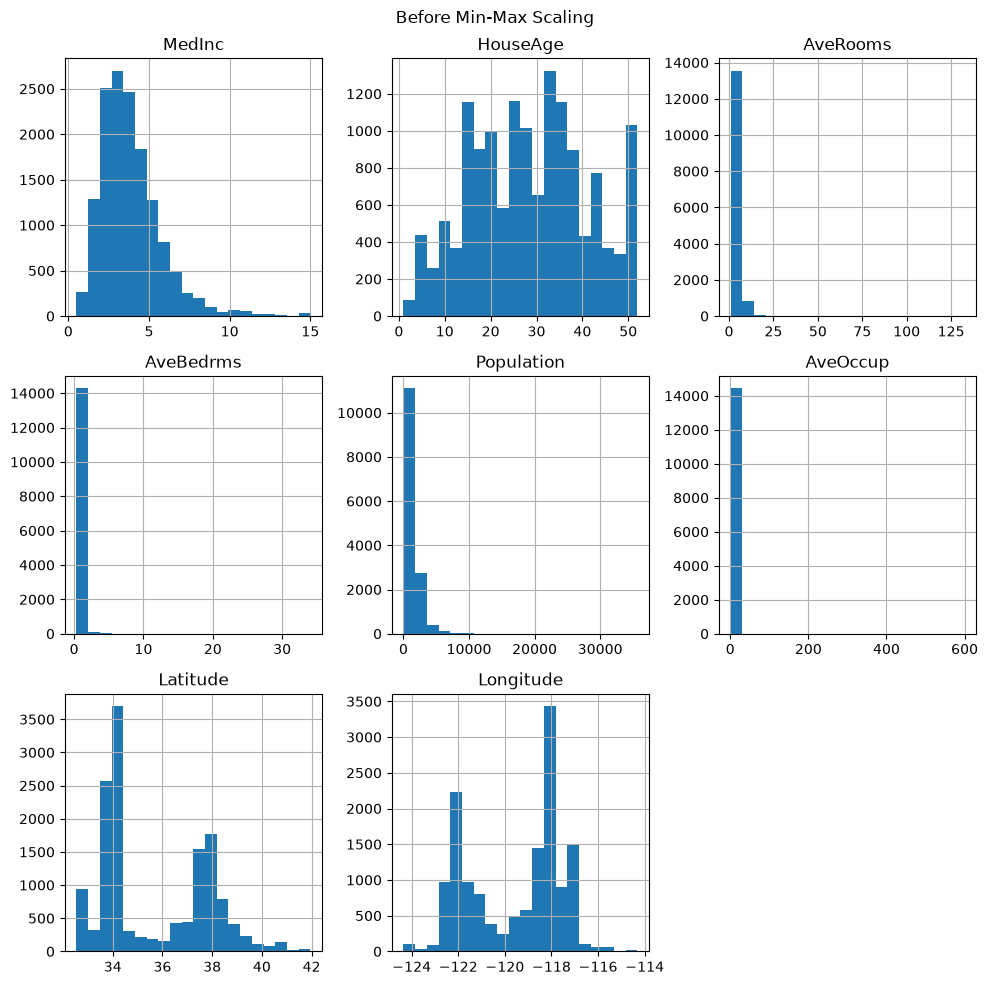

In [10]:
X_train.hist(bins=20, figsize=(10, 10))

plt.suptitle("Before Min-Max Scaling")
plt.tight_layout()

plt.show()

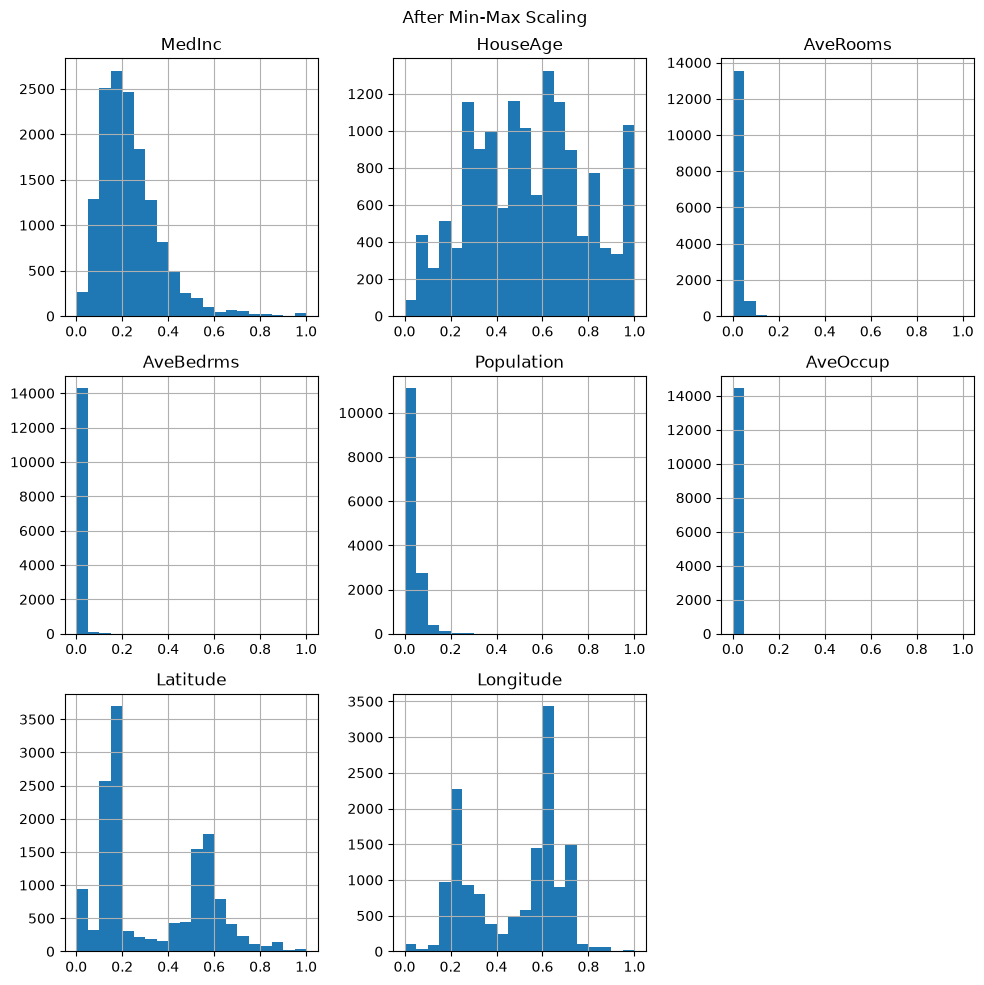

In [11]:
X_train_scaled.hist(bins=20, figsize=(10, 10))

plt.suptitle("After Min-Max Scaling")
plt.tight_layout()

plt.show()

In [12]:
comparison = pd.concat(
    [X_train.head(), X_train_scaled.head()],
    axis=1,
    keys=["Original Data", "Scaled Data"]
)

comparison

Original Data                                                             \
            MedInc HouseAge  AveRooms AveBedrms Population  AveOccup Latitude   
1989        1.9750     52.0  2.800000  0.700000      193.0  4.825000    36.73   
256         2.2604     43.0  3.671480  1.184116      836.0  3.018051    37.77   
7887        6.2990     17.0  6.478022  1.087912     1387.0  3.810440    33.87   
4581        1.7199     17.0  2.518000  1.196000     3051.0  3.051000    34.06   
1993        2.2206     50.0  4.622754  1.161677      606.0  3.628743    36.73   

               Scaled Data                                                     \
     Longitude      MedInc  HouseAge  AveRooms AveBedrms Population  AveOccup   
1989   -119.79    0.101730  1.000000  0.014837  0.010870   0.005325  0.006803   
256    -122.21    0.121412  0.823529  0.021455  0.025221   0.023347  0.003787   
7887   -118.04    0.399932  0.313725  0.042767  0.022369   0.038790  0.005110   
4581   -118.28    0.084137  0.313725  0.012696  0.025573   0.085428  0.003842   
1993   -119.81    0.118667  0.960784  0.028679  0.024556   0.016901  0.004806   

                          
      Latitude Longitude  
1989  0.445271  0.454183  
256   0.555792  0.213147  
7887  0.141339  0.628486  
4581  0.161530  0.604582  
1993  0.445271  0.452191